# Hack-o-Week — Weeks 7 & 8
## Supervised Learning: Regression & Classification

**Dataset:** `student_habits_performance.csv`

Weeks 3–4 gave you the tools, Weeks 5–6 gave you the maths. Now you build actual models
with **scikit-learn** — and because you did Week 5–6, none of it is a black box.

### Roadmap
| Part | Models | Question answered |
|---|---|---|
| A | Preprocessing | how do I turn a DataFrame into `X` and `y`? |
| B | Linear Regression | **how many marks** will this student score? |
| C | Polynomial Regression | what if the relationship is curved? (bias–variance) |
| D | Ridge / Lasso / ElasticNet | how do I stop the model memorising noise? |
| E | Logistic Regression | will this student **pass or fail**? |
| F | K-Nearest Neighbours | can I predict from similar students alone? |
| G | Comparison | which model wins, and why? |

> Week 9–10 covers evaluation properly (cross-validation, ROC-AUC, pipelines). Here we use
> a single train/test split so the focus stays on the models themselves.

### 0 · Setup

In [1]:
import os
import numpy as np
import pandas as pd

FILENAME = "student_habits_performance.csv"

# Works whether you run this notebook from the repo (notebooks/ folder),
# from the repo root, or in Google Colab.
CANDIDATES = [
    FILENAME,
    os.path.join("data", FILENAME),
    os.path.join("..", "data", FILENAME),
    os.path.join("/content", FILENAME),
]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:  # running in Colab without the repo -> upload the CSV once
        from google.colab import files
        print("CSV not found. Please upload student_habits_performance.csv")
        files.upload()
        DATA_PATH = FILENAME
    except ImportError:
        raise FileNotFoundError(
            "Put student_habits_performance.csv in a data/ folder next to this notebook."
        )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()

Loaded: ../data/student_habits_performance.csv | shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("plotting configured")

plotting configured


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  LogisticRegression)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score)
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
print("scikit-learn ready")

scikit-learn ready


---
# Part A · Preparing the data

Three jobs before any model sees the data:

1. **Split X and y** — features vs target.
2. **Encode categoricals** — models need numbers. One-hot encoding turns
   `diet_quality ∈ {Poor, Fair, Good}` into three 0/1 columns.
3. **Split train / test** — fit on train, judge on test. *Never* look at test until the end.

> **Why scale?** Ridge, Lasso, Logistic Regression and KNN all measure distance or penalise
> coefficient size, so a feature measured in the tens (attendance ≈ 85) would swamp one
> measured in single digits (sleep ≈ 7). Plain `LinearRegression` does not care, but
> scaling makes its coefficients comparable to each other.

In [4]:
data = df.copy()
data["parental_education_level"] = data["parental_education_level"].fillna("Unknown")

NUMERIC = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
           "attendance_percentage", "sleep_hours", "exercise_frequency",
           "mental_health_rating"]
CATEGORICAL = ["gender", "part_time_job", "diet_quality", "parental_education_level",
               "internet_quality", "extracurricular_participation"]
TARGET = "exam_score"

print("numeric features    :", len(NUMERIC))
print("categorical features:", len(CATEGORICAL))
data[NUMERIC + CATEGORICAL + [TARGET]].head()

numeric features    : 8
categorical features: 6


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation,exam_score
0,23,0.0,1.2,1.1,85.0,8.0,6,8,Female,No,Fair,Master,Average,Yes,56.2
1,20,6.9,2.8,2.3,97.3,4.6,6,8,Female,No,Good,High School,Average,No,100.0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,Male,No,Poor,High School,Poor,No,34.3
3,23,1.0,3.9,1.0,71.0,9.2,4,1,Female,No,Poor,Master,Good,Yes,26.8
4,19,5.0,4.4,0.5,90.9,4.9,3,1,Female,No,Fair,Master,Good,No,66.4


In [5]:
# One-hot encode. drop="first" avoids the "dummy variable trap"
# (perfectly collinear columns -> singular X^T X, exactly the Week 5-6 problem).
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
cat_encoded = encoder.fit_transform(data[CATEGORICAL])
cat_names = encoder.get_feature_names_out(CATEGORICAL)

X_full = pd.concat([
    data[NUMERIC].reset_index(drop=True),
    pd.DataFrame(cat_encoded, columns=cat_names),
], axis=1)
y_full = data[TARGET].to_numpy()

print("design matrix shape:", X_full.shape)
print("\nencoded categorical columns:")
print(list(cat_names))
X_full.head(3)

design matrix shape: (1000, 19)

encoded categorical columns:
['gender_Male', 'gender_Other', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master', 'parental_education_level_Unknown', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,20,6.9,2.8,2.3,97.3,4.6,6,8,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE)

print(f"train: {X_train.shape[0]} rows | test: {X_test.shape[0]} rows")
print(f"train mean score {y_train.mean():.2f} | test mean score {y_test.mean():.2f}"
      "   <- similar, so the split is representative")

scaler = StandardScaler().fit(X_train)      # FIT on train only!
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)         # transform test with TRAIN statistics
print("\ntrain feature means after scaling:", X_train_s.mean(axis=0)[:4].round(6))
print("test  feature means after scaling:", X_test_s.mean(axis=0)[:4].round(3),
      " <- not exactly 0, and that is correct")

train: 800 rows | test: 200 rows
train mean score 69.83 | test mean score 68.70   <- similar, so the split is representative

train feature means after scaling: [-0. -0.  0.  0.]
test  feature means after scaling: [ 0.031 -0.026  0.088 -0.005]  <- not exactly 0, and that is correct


> **The most common beginner mistake:** calling `scaler.fit()` on the whole dataset. That
> leaks information about the test set into training and inflates your score. Always
> `fit` on train, `transform` both. Week 9–10 shows how `Pipeline` makes this automatic.

### The metrics we will use

| Metric | Formula | Reads as |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y-\hat y|$ | average error, in marks |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat y)^2}$ | like MAE but punishes big misses |
| **R²** | $1-\frac{RSS}{TSS}$ | fraction of variance explained; 1.0 = perfect, 0 = no better than predicting the mean |

In [7]:
def regression_report(name, model, Xtr, ytr, Xte, yte, verbose=True):
    """Fit a regressor and return a dict of train/test metrics."""
    model.fit(Xtr, ytr)
    pred_tr, pred_te = model.predict(Xtr), model.predict(Xte)
    res = {
        "model": name,
        "train_r2": r2_score(ytr, pred_tr),
        "test_r2": r2_score(yte, pred_te),
        "test_rmse": np.sqrt(mean_squared_error(yte, pred_te)),
        "test_mae": mean_absolute_error(yte, pred_te),
    }
    if verbose:
        print(f"{name}")
        print(f"  R² train {res['train_r2']:.4f} | R² test {res['test_r2']:.4f}"
              f" | RMSE {res['test_rmse']:.3f} | MAE {res['test_mae']:.3f}")
    return res

results = []
print("helper ready")

helper ready


---
# Part B · Linear Regression

$$\hat{y} = w_1x_1 + w_2x_2 + \dots + w_px_p + b$$

Fitted by minimising the sum of squared residuals — exactly the normal equation you
derived in Week 5–6. `sklearn` solves it with `lstsq` under the hood.

**Reading a coefficient:** *"holding every other feature fixed, a one-unit increase in
this feature changes the predicted score by `w` marks."*

In [8]:
lin = LinearRegression()
results.append(regression_report("Linear Regression", lin,
                                 X_train_s, y_train, X_test_s, y_test))

coefs = (pd.Series(lin.coef_, index=X_full.columns)
           .sort_values(key=abs, ascending=False))
print("\nintercept (score of an 'average' student):", round(lin.intercept_, 3))
print("\nCoefficients on STANDARDISED features (so they are directly comparable):")
print(coefs.round(3).to_string())

Linear Regression
  R² train 0.9021 | R² test 0.8968 | RMSE 5.146 | MAE 4.189

intercept (score of an 'average' student): 69.827

Coefficients on STANDARDISED features (so they are directly comparable):
study_hours_per_day                     14.145
mental_health_rating                     5.564
social_media_hours                      -3.134
exercise_frequency                       2.656
netflix_hours                           -2.534
sleep_hours                              2.422
attendance_percentage                    1.360
diet_quality_Good                       -0.464
parental_education_level_Master         -0.260
parental_education_level_Unknown        -0.245
parental_education_level_High School    -0.221
diet_quality_Poor                       -0.213
gender_Other                             0.166
part_time_job_Yes                        0.152
age                                      0.121
internet_quality_Good                   -0.111
gender_Male                              0.06

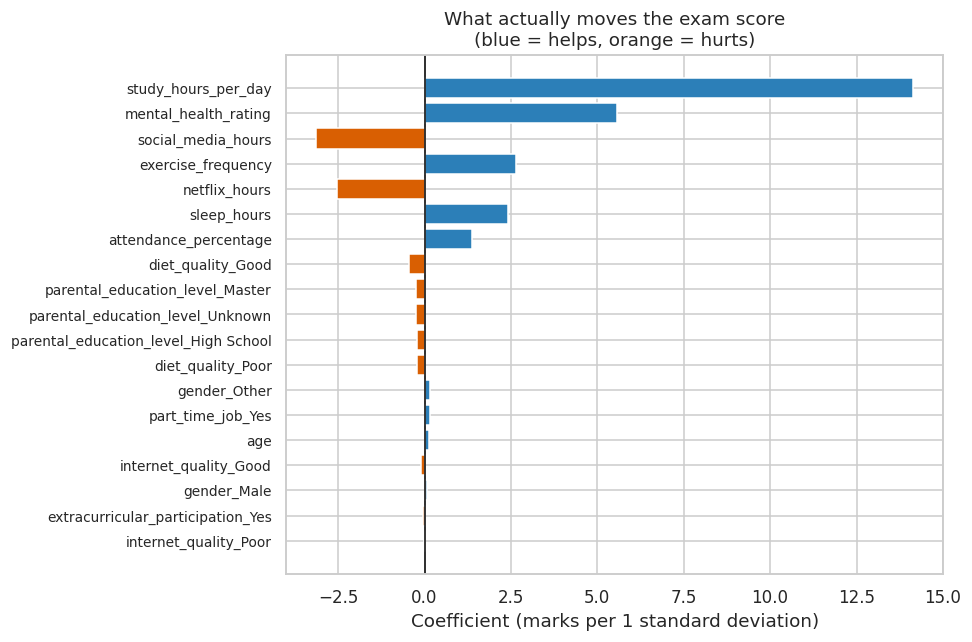

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2c7fb8" if v > 0 else "#d95f02" for v in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coefficient (marks per 1 standard deviation)")
ax.set_title("What actually moves the exam score\n(blue = helps, orange = hurts)")
fig.tight_layout(); plt.show()

Read that chart carefully: **one standard deviation more study time (≈1.5 h/day) is worth
about 14 marks**, dwarfing everything else. Mental health rating is a clear second at ~5.5
marks. Social media and Netflix each cost 2–3 marks per standard deviation. Gender,
part-time job, diet, internet quality and parental education contribute almost nothing —
under half a mark each.

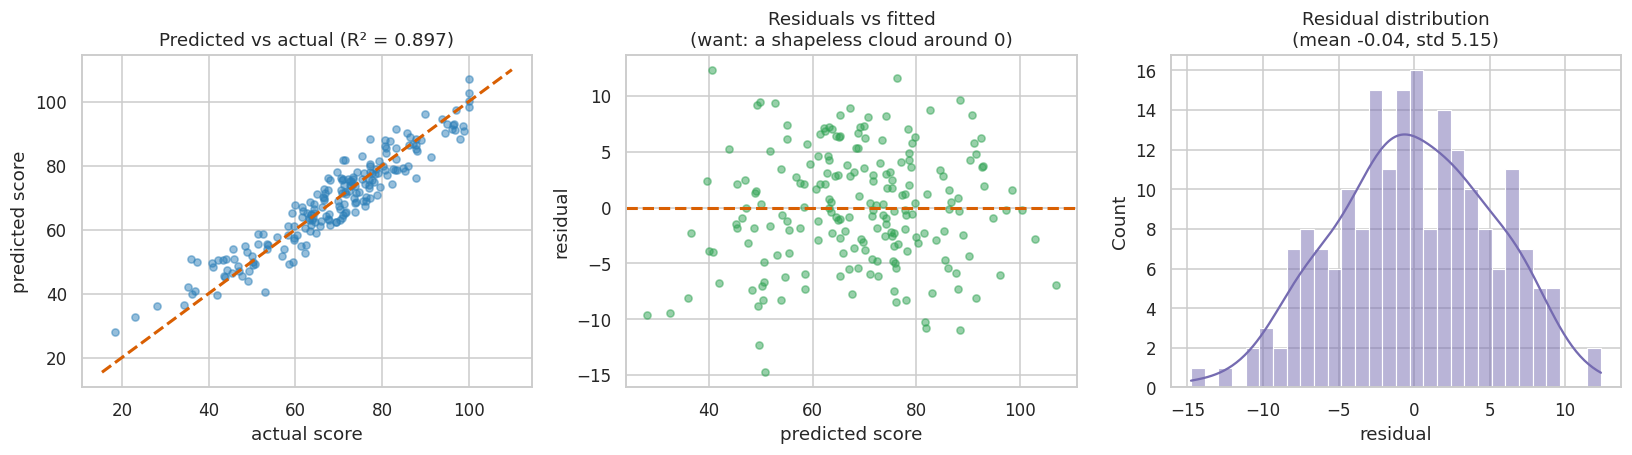

In [10]:
# Diagnostic plots — always look at your residuals, never just the R²
y_pred = lin.predict(X_test_s)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=22, color="#2c7fb8")
lims = [min(y_test.min(), y_pred.min()) - 3, max(y_test.max(), y_pred.max()) + 3]
axes[0].plot(lims, lims, "--", color="#d95f02", lw=2)
axes[0].set_xlabel("actual score"); axes[0].set_ylabel("predicted score")
axes[0].set_title(f"Predicted vs actual (R² = {r2_score(y_test, y_pred):.3f})")

axes[1].scatter(y_pred, residuals, alpha=0.5, s=22, color="#31a354")
axes[1].axhline(0, color="#d95f02", ls="--", lw=2)
axes[1].set_xlabel("predicted score"); axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs fitted\n(want: a shapeless cloud around 0)")

sns.histplot(residuals, kde=True, bins=30, color="#756bb1", ax=axes[2])
axes[2].set_title(f"Residual distribution\n(mean {residuals.mean():.2f}, "
                  f"std {residuals.std():.2f})")
axes[2].set_xlabel("residual")

fig.tight_layout(); plt.show()

The residual cloud is centred on zero with no funnel shape and the histogram is roughly
bell-shaped — the linear model's assumptions hold up well here. If you saw a curve or a
widening fan, that would be your signal to add non-linear terms.

---
# Part C · Polynomial Regression & the bias–variance trade-off

Polynomial regression is still a *linear* model — linear in the **coefficients**. You just
feed it extra columns: $x, x^2, x^3, \dots$ (and interaction terms like $x_1x_2$).

This is the cleanest way to see the central trade-off in all of ML:

| | Bias | Variance | Symptom |
|---|---|---|---|
| **Underfitting** | high | low | bad on train *and* test |
| **Just right** | balanced | balanced | test ≈ train, both good |
| **Overfitting** | low | high | great on train, poor on test |

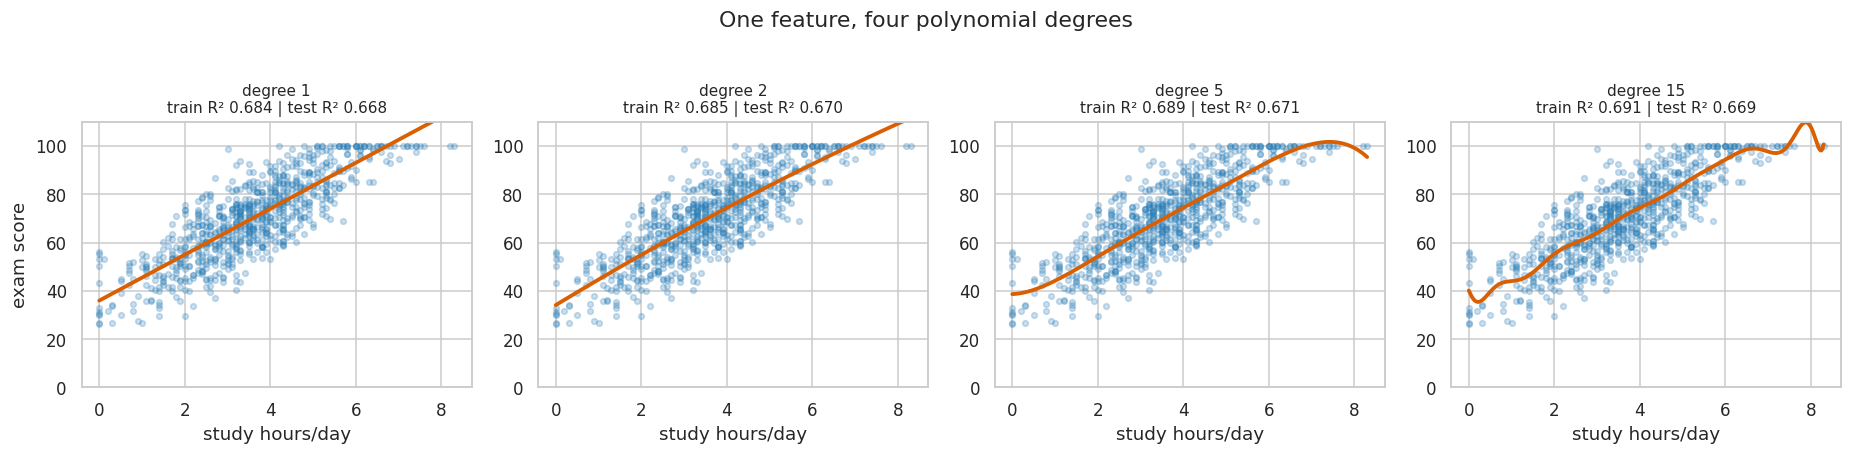

In [11]:
# Start with ONE feature so the curves are visible
x_single = data[["study_hours_per_day"]].to_numpy()
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    x_single, y_full, test_size=0.2, random_state=RANDOM_STATE)

grid = np.linspace(x_single.min(), x_single.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, degree in zip(axes, [1, 2, 5, 15]):
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    model.fit(Xs_tr, ys_tr)
    ax.scatter(Xs_tr, ys_tr, alpha=0.25, s=14, color="#2c7fb8", label="train")
    ax.plot(grid, model.predict(grid), color="#d95f02", lw=2.5)
    ax.set_title(f"degree {degree}\ntrain R² {model.score(Xs_tr, ys_tr):.3f} | "
                 f"test R² {model.score(Xs_te, ys_te):.3f}", fontsize=10)
    ax.set_xlabel("study hours/day"); ax.set_ylim(0, 110)
axes[0].set_ylabel("exam score")
fig.suptitle("One feature, four polynomial degrees", y=1.03)
fig.tight_layout(); plt.show()

degree 1:    8 features | train R² 0.9010 | test R² 0.8989
degree 2:   44 features | train R² 0.9119 | test R² 0.9092
degree 3:  164 features | train R² 0.9319 | test R² 0.8722


degree 4:  494 features | train R² 0.9672 | test R² 0.6528


degree 5: 1286 features | train R² 1.0000 | test R² -35.4865


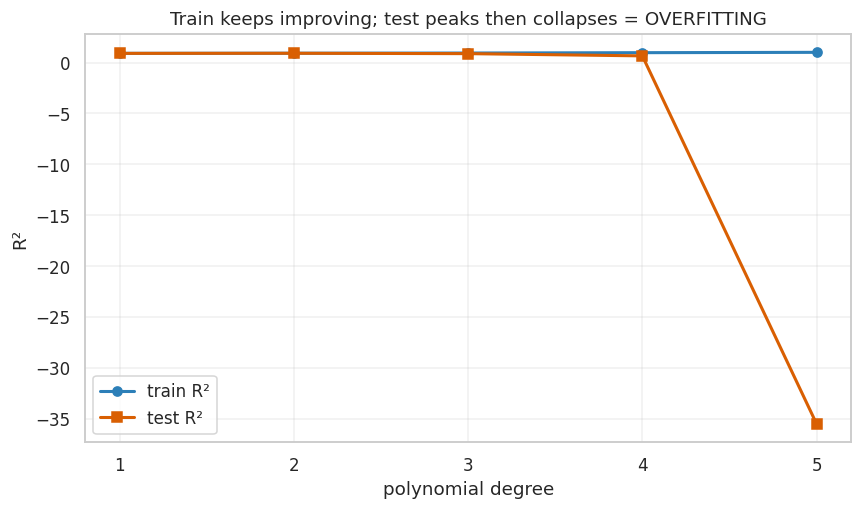

In [12]:
# The classic complexity curve, now on ALL features
degrees = range(1, 6)
train_scores, test_scores = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(X_train[NUMERIC])
    Xte_p = poly.transform(X_test[NUMERIC])
    sc = StandardScaler().fit(Xtr_p)
    m = LinearRegression().fit(sc.transform(Xtr_p), y_train)
    train_scores.append(m.score(sc.transform(Xtr_p), y_train))
    test_scores.append(m.score(sc.transform(Xte_p), y_test))
    print(f"degree {d}: {Xtr_p.shape[1]:>4} features | "
          f"train R² {train_scores[-1]:.4f} | test R² {test_scores[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(list(degrees), train_scores, "o-", label="train R²", color="#2c7fb8", lw=2)
ax.plot(list(degrees), test_scores, "s-", label="test R²", color="#d95f02", lw=2)
ax.set_xlabel("polynomial degree"); ax.set_ylabel("R²")
ax.set_title("Train keeps improving; test peaks then collapses = OVERFITTING")
ax.set_xticks(list(degrees)); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

In [13]:
# Keep the best degree for the comparison table
best_degree = int(np.argmax(test_scores)) + 1
print("best degree by test R²:", best_degree)

poly_model = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(), LinearRegression())
results.append(regression_report(f"Polynomial (deg {best_degree})", poly_model,
                                 X_train[NUMERIC], y_train, X_test[NUMERIC], y_test))

best degree by test R²: 2


Polynomial (deg 2)
  R² train 0.9119 | R² test 0.9092 | RMSE 4.825 | MAE 3.901


---
# Part D · Regularisation — Ridge, Lasso, ElasticNet

Overfitting shows up as **huge coefficients** that cancel each other out. Regularisation
adds a penalty on coefficient size to the loss:

| Model | Penalty | Effect |
|---|---|---|
| **Ridge** (L2) | $\alpha\sum w_j^2$ | shrinks all coefficients smoothly toward 0, never exactly 0 |
| **Lasso** (L1) | $\alpha\sum|w_j|$ | drives weak coefficients to **exactly 0** → automatic feature selection |
| **ElasticNet** | mix of both | shrinks *and* selects |

`alpha` (α) is the strength: α = 0 is plain least squares; α → ∞ pushes every coefficient
to zero. **Regularised models require scaled features** — the penalty is applied to the raw
coefficient values, so unscaled features get penalised unfairly.

In [14]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1, max_iter=10000)
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

results.append(regression_report("Ridge (α=1)", ridge, X_train_s, y_train, X_test_s, y_test))
results.append(regression_report("Lasso (α=0.1)", lasso, X_train_s, y_train, X_test_s, y_test))
results.append(regression_report("ElasticNet (α=0.1)", enet, X_train_s, y_train, X_test_s, y_test))

comp = pd.DataFrame({
    "Linear": lin.coef_, "Ridge": ridge.coef_,
    "Lasso": lasso.coef_, "ElasticNet": enet.coef_,
}, index=X_full.columns).round(3)
print("\nCoefficients side by side:")
print(comp.to_string())
print(f"\nLasso zeroed out {(lasso.coef_ == 0).sum()} of {len(lasso.coef_)} features:")
print("  ", list(X_full.columns[lasso.coef_ == 0]))

Ridge (α=1)
  R² train 0.9021 | R² test 0.8967 | RMSE 5.147 | MAE 4.190
Lasso (α=0.1)
  R² train 0.9014 | R² test 0.8976 | RMSE 5.124 | MAE 4.168
ElasticNet (α=0.1)
  R² train 0.8994 | R² test 0.8930 | RMSE 5.239 | MAE 4.262

Coefficients side by side:
                                      Linear   Ridge   Lasso  ElasticNet
age                                    0.121   0.121   0.022       0.074
study_hours_per_day                   14.145  14.127  14.048      13.419
social_media_hours                    -3.134  -3.130  -3.054      -2.951
netflix_hours                         -2.534  -2.532  -2.440      -2.382
attendance_percentage                  1.360   1.358   1.257       1.259
sleep_hours                            2.422   2.418   2.337       2.252
exercise_frequency                     2.656   2.653   2.553       2.474
mental_health_rating                   5.564   5.557   5.463       5.252
gender_Male                            0.067   0.066   0.000       0.000
gender_Other     

### Coefficient paths — watch regularisation bite

Sweep α across several orders of magnitude and plot every coefficient. Ridge shrinks
everything gradually; Lasso snaps coefficients to zero one by one.

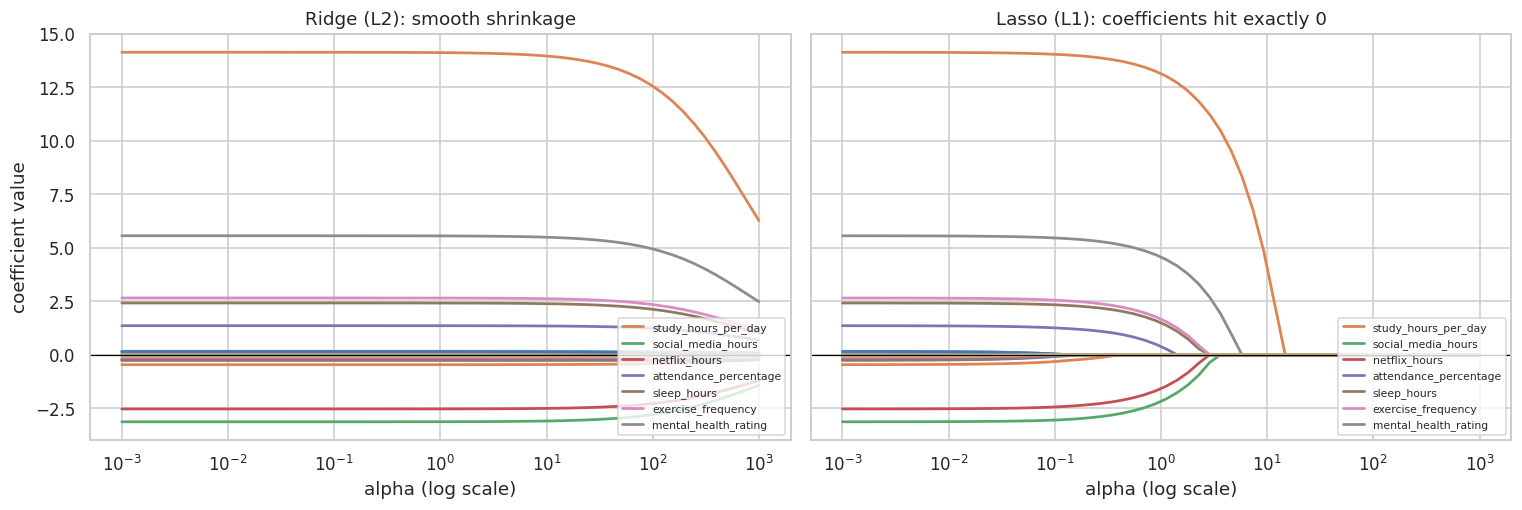

In [15]:
alphas = np.logspace(-3, 3, 60)
ridge_path = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=20000).fit(X_train_s, y_train).coef_
                       for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, path, title in [(axes[0], ridge_path, "Ridge (L2): smooth shrinkage"),
                        (axes[1], lasso_path, "Lasso (L1): coefficients hit exactly 0")]:
    for j, name in enumerate(X_full.columns):
        ax.plot(alphas, path[:, j], lw=1.8,
                label=name if abs(path[0, j]) > 0.8 else None)
    ax.set_xscale("log"); ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("alpha (log scale)"); ax.set_title(title)
    ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("coefficient value")
fig.tight_layout(); plt.show()

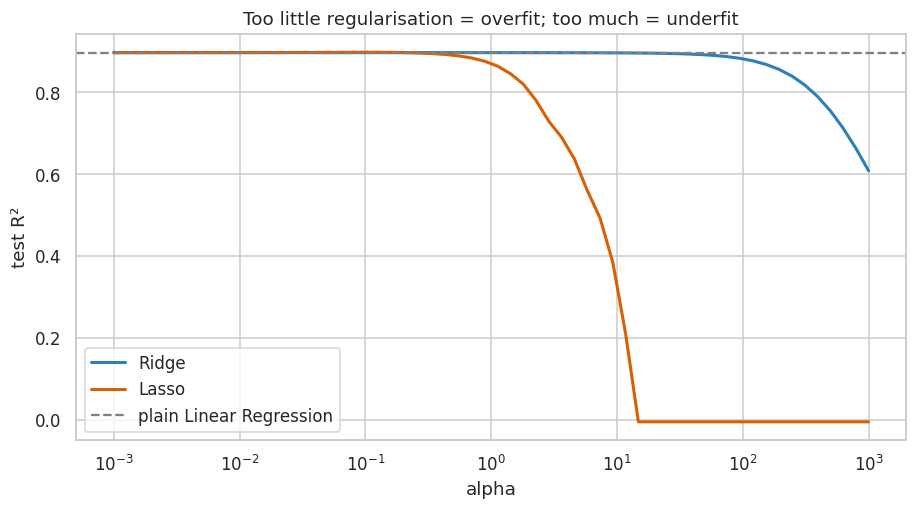

best Ridge alpha ≈ 0.0010 (test R² 0.8968)
best Lasso alpha ≈ 0.1081 (test R² 0.8977)


In [16]:
# How does alpha affect ACCURACY? This is how you would pick alpha
# (properly, with cross-validation — see Week 9-10).
r2_ridge = [Ridge(alpha=a).fit(X_train_s, y_train).score(X_test_s, y_test) for a in alphas]
r2_lasso = [Lasso(alpha=a, max_iter=20000).fit(X_train_s, y_train).score(X_test_s, y_test)
            for a in alphas]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(alphas, r2_ridge, lw=2, color="#2c7fb8", label="Ridge")
ax.plot(alphas, r2_lasso, lw=2, color="#d95f02", label="Lasso")
ax.axhline(lin.score(X_test_s, y_test), ls="--", color="gray",
           label="plain Linear Regression")
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("test R²")
ax.set_title("Too little regularisation = overfit; too much = underfit")
ax.legend(); fig.tight_layout(); plt.show()

print(f"best Ridge alpha ≈ {alphas[int(np.argmax(r2_ridge))]:.4f} "
      f"(test R² {max(r2_ridge):.4f})")
print(f"best Lasso alpha ≈ {alphas[int(np.argmax(r2_lasso))]:.4f} "
      f"(test R² {max(r2_lasso):.4f})")

On this dataset regularisation barely helps — with 1,000 rows and ~15 features there is
simply not much to overfit. **That is a real and useful result.** Regularisation earns its
keep when features are many, correlated, or scarce relative to rows. Knowing *when a
technique does not matter* is as valuable as knowing how to run it.

---
# Part E · Logistic Regression (classification)

Switch the question from *"how many marks?"* to *"pass or fail?"*.

Logistic regression takes the same linear combination and squashes it through the
**sigmoid** you met in Week 5–6:

$$z = \mathbf{w}\cdot\mathbf{x}+b, \qquad P(\text{pass}) = \sigma(z) = \frac{1}{1+e^{-z}}$$

- It outputs a **probability** in (0, 1), not a raw score.
- It is trained by minimising **binary cross-entropy**, not squared error.
- Despite the name it is a **classifier**.

`coef_` is in **log-odds**. Exponentiate it and you get an **odds ratio**: how much the
odds of passing multiply for a one-standard-deviation increase in that feature.

In [17]:
y_class = (data[TARGET] >= 60).astype(int).to_numpy()   # 1 = pass, 0 = fail

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_full, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class)

scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = scaler_c.transform(Xc_train), scaler_c.transform(Xc_test)

print("class balance overall:", np.bincount(y_class), f"-> {y_class.mean():.1%} pass")
print("train:", np.bincount(yc_train), "| test:", np.bincount(yc_test),
      "  <- stratify kept the ratio identical")

class balance overall: [280 720] -> 72.0% pass
train: [224 576] | test: [ 56 144]   <- stratify kept the ratio identical


In [18]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(Xc_train_s, yc_train)

pred = logreg.predict(Xc_test_s)
proba = logreg.predict_proba(Xc_test_s)[:, 1]

print(f"accuracy : {accuracy_score(yc_test, pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(yc_test, proba):.4f}")
print("\n", classification_report(yc_test, pred, target_names=["fail", "pass"]))

accuracy : 0.9150
ROC-AUC  : 0.9766

               precision    recall  f1-score   support

        fail       0.87      0.82      0.84        56
        pass       0.93      0.95      0.94       144

    accuracy                           0.92       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.91      0.92      0.91       200



In [19]:
# Coefficients as odds ratios — the interpretable output
odds = pd.DataFrame({
    "log_odds": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0]),
}, index=X_full.columns).sort_values("odds_ratio", ascending=False).round(3)
print(odds.to_string())
print("\nRead: odds ratio 2.0 = the odds of passing DOUBLE per +1 std dev of that feature.")
print("      odds ratio 0.5 = the odds HALVE.")

                                      log_odds  odds_ratio
study_hours_per_day                      4.411      82.317
mental_health_rating                     1.535       4.640
exercise_frequency                       0.971       2.641
sleep_hours                              0.891       2.437
attendance_percentage                    0.486       1.626
part_time_job_Yes                        0.094       1.098
gender_Male                              0.090       1.094
gender_Other                             0.033       1.034
parental_education_level_High School     0.018       1.018
parental_education_level_Master         -0.009       0.991
age                                     -0.010       0.990
internet_quality_Good                   -0.037       0.963
diet_quality_Poor                       -0.086       0.918
internet_quality_Poor                   -0.092       0.912
parental_education_level_Unknown        -0.144       0.866
extracurricular_participation_Yes       -0.217       0.8

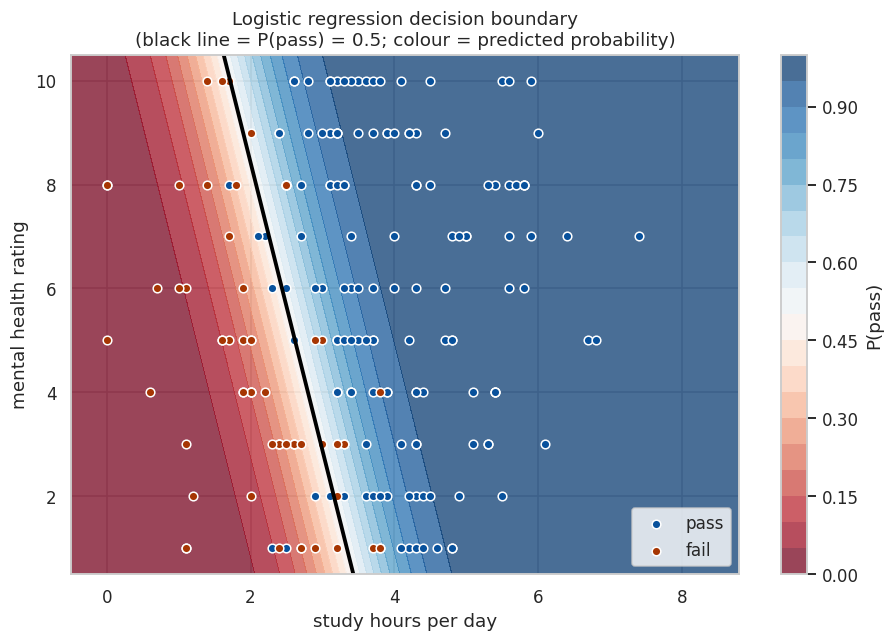

2-feature model accuracy: 0.875


In [20]:
# The decision boundary, drawn in 2-D so you can actually see it
two = ["study_hours_per_day", "mental_health_rating"]
X2 = data[two].to_numpy()
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class)
sc2 = StandardScaler().fit(X2_tr)
lr2 = LogisticRegression(max_iter=2000).fit(sc2.transform(X2_tr), y2_tr)

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min()-.5, X2[:, 0].max()+.5, 300),
                     np.linspace(X2[:, 1].min()-.5, X2[:, 1].max()+.5, 300))
Zp = lr2.predict_proba(sc2.transform(np.c_[xx.ravel(), yy.ravel()]))[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8.5, 6))
cf = ax.contourf(xx, yy, Zp, levels=20, cmap="RdBu", alpha=0.75)
ax.contour(xx, yy, Zp, levels=[0.5], colors="black", linewidths=2.5)
ax.scatter(X2_te[y2_te == 1, 0], X2_te[y2_te == 1, 1], c="#08519c",
           edgecolor="white", s=32, label="pass")
ax.scatter(X2_te[y2_te == 0, 0], X2_te[y2_te == 0, 1], c="#a63603",
           edgecolor="white", s=32, label="fail")
ax.set_xlabel("study hours per day"); ax.set_ylabel("mental health rating")
ax.set_title("Logistic regression decision boundary\n"
             "(black line = P(pass) = 0.5; colour = predicted probability)")
fig.colorbar(cf, ax=ax, label="P(pass)")
ax.legend(loc="lower right"); fig.tight_layout(); plt.show()

print("2-feature model accuracy:", round(lr2.score(sc2.transform(X2_te), y2_te), 4))

The boundary is a **straight line** — that is what "linear classifier" means. It can be
tilted and shifted, but it can never curve. When your classes are not linearly separable,
you need a model that can bend: KNN, trees, SVM with a kernel, or a neural network.

---
# Part F · K-Nearest Neighbours

KNN has **no training phase at all**. To classify a new student:

1. Compute the distance to every training student (Euclidean, from Week 5–6).
2. Take the `k` closest.
3. Vote.

| | |
|---|---|
| **Pros** | zero assumptions, naturally non-linear, trivial to explain |
| **Cons** | slow at prediction, needs scaling, degrades badly in high dimensions |

**Scaling is not optional here.** Distance is dominated by whichever feature has the
largest numeric range — `attendance_percentage` spans ~44 units while `study_hours_per_day`
spans only ~8, so on raw data KNN quietly decides that attendance is 5× more important than
study hours. Let's prove it on three features.

In [21]:
demo_feats = ["study_hours_per_day", "attendance_percentage", "mental_health_rating"]
Xd = data[demo_feats].to_numpy()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    Xd, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class)
sc_d = StandardScaler().fit(Xd_tr)

print("raw feature ranges:", dict(zip(demo_feats, (Xd.max(0) - Xd.min(0)).round(1))))

raw_acc = KNeighborsClassifier(15).fit(Xd_tr, yd_tr).score(Xd_te, yd_te)
scl_acc = (KNeighborsClassifier(15)
           .fit(sc_d.transform(Xd_tr), yd_tr)
           .score(sc_d.transform(Xd_te), yd_te))

print(f"\nKNN on RAW features    : {raw_acc:.4f}")
print(f"KNN on SCALED features : {scl_acc:.4f}")
print("\nSame model, same k, same data. The only difference is scaling.")

raw feature ranges: {'study_hours_per_day': np.float64(8.3), 'attendance_percentage': np.float64(44.0), 'mental_health_rating': np.float64(9.0)}

KNN on RAW features    : 0.8400
KNN on SCALED features : 0.8750

Same model, same k, same data. The only difference is scaling.


On the **full** 19-column feature set the gap mostly disappears — but not because scaling
stopped mattering. With 19 dimensions, most of which are pure noise here, every student is
roughly equidistant from every other one. That is the **curse of dimensionality**, and it
is why KNN will lose to logistic regression in Part G. Scaling fixes the units; it cannot
fix having too many useless features.

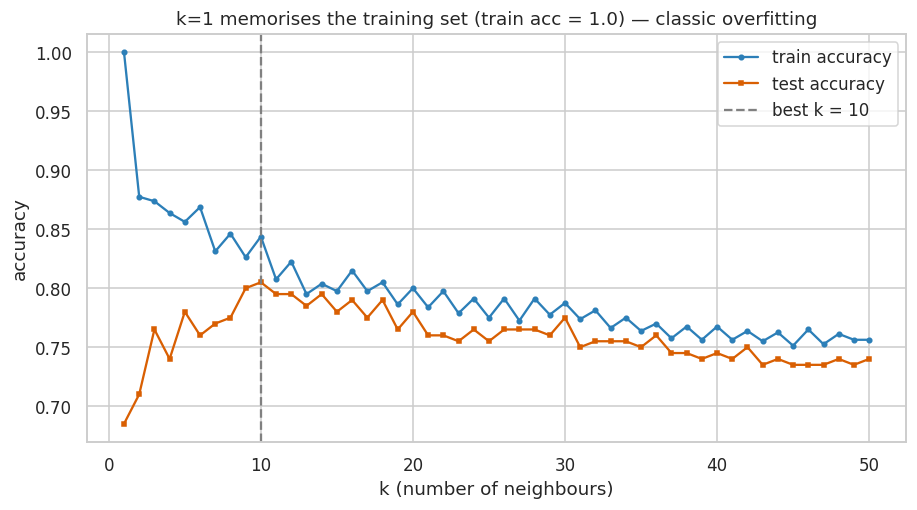

best k = 10 with test accuracy 0.8050


In [22]:
# Choosing k: small k = jagged/overfit, large k = smooth/underfit
ks = range(1, 51)
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(Xc_train_s, yc_train)
    train_acc.append(m.score(Xc_train_s, yc_train))
    test_acc.append(m.score(Xc_test_s, yc_test))

best_k = list(ks)[int(np.argmax(test_acc))]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(list(ks), train_acc, "o-", ms=3, label="train accuracy", color="#2c7fb8")
ax.plot(list(ks), test_acc, "s-", ms=3, label="test accuracy", color="#d95f02")
ax.axvline(best_k, ls="--", color="gray", label=f"best k = {best_k}")
ax.set_xlabel("k (number of neighbours)"); ax.set_ylabel("accuracy")
ax.set_title("k=1 memorises the training set (train acc = 1.0) — classic overfitting")
ax.legend(); fig.tight_layout(); plt.show()

print(f"best k = {best_k} with test accuracy {max(test_acc):.4f}")

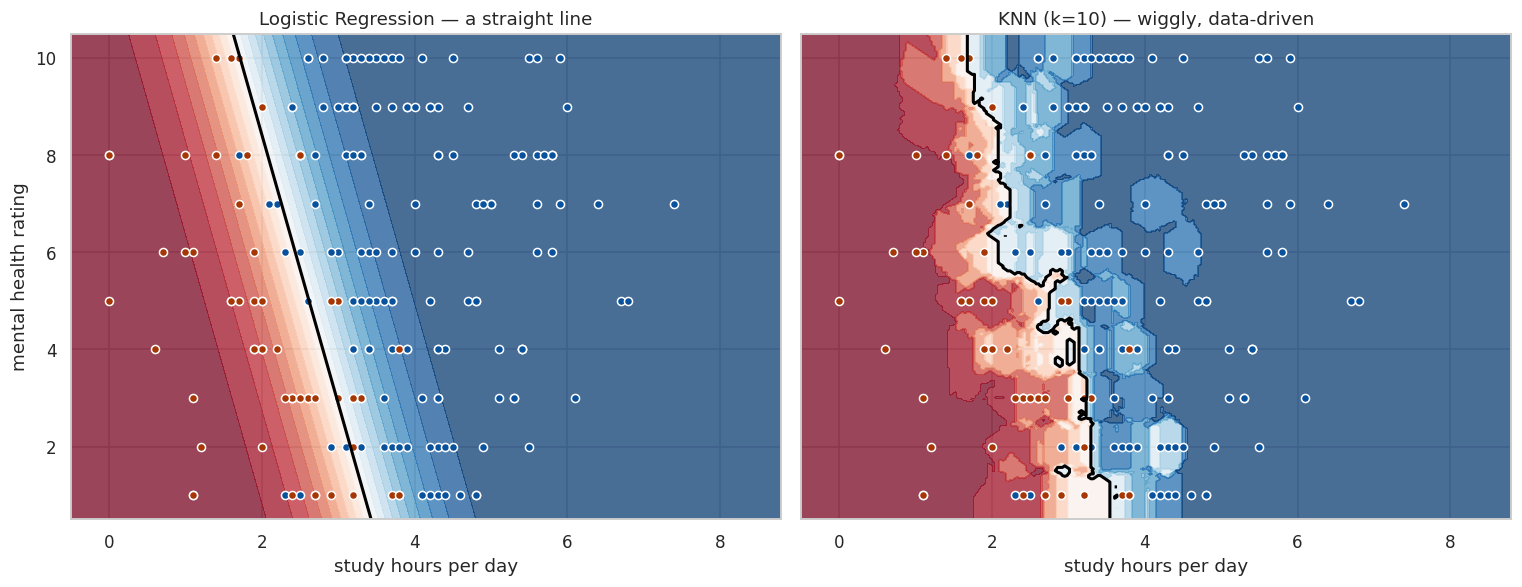

In [23]:
# KNN decision boundary on the same two features — compare its shape to logistic regression
knn2 = KNeighborsClassifier(n_neighbors=best_k).fit(sc2.transform(X2_tr), y2_tr)
Zk = knn2.predict_proba(sc2.transform(np.c_[xx.ravel(), yy.ravel()]))[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, Z, title in [(axes[0], Zp, "Logistic Regression — a straight line"),
                     (axes[1], Zk, f"KNN (k={best_k}) — wiggly, data-driven")]:
    cf = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.75)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X2_te[y2_te == 1, 0], X2_te[y2_te == 1, 1], c="#08519c",
               edgecolor="white", s=28)
    ax.scatter(X2_te[y2_te == 0, 0], X2_te[y2_te == 0, 1], c="#a63603",
               edgecolor="white", s=28)
    ax.set_xlabel("study hours per day"); ax.set_title(title)
axes[0].set_ylabel("mental health rating")
fig.tight_layout(); plt.show()

In [24]:
# KNN also does regression: predict the mean score of the k nearest students
knn_reg = KNeighborsRegressor(n_neighbors=10)
results.append(regression_report("KNN Regressor (k=10)", knn_reg,
                                 X_train_s, y_train, X_test_s, y_test))

KNN Regressor (k=10)
  R² train 0.6082 | R² test 0.5121 | RMSE 11.185 | MAE 8.693


---
# Part G · Putting it together

REGRESSION — predicting the exam score

                      train_r2  test_r2  test_rmse  test_mae  overfit_gap
model                                                                    
Polynomial (deg 2)      0.9119   0.9092     4.8251    3.9006       0.0027
Lasso (α=0.1)           0.9014   0.8976     5.1236    4.1684       0.0038
Linear Regression       0.9021   0.8968     5.1455    4.1893       0.0053
Ridge (α=1)             0.9021   0.8967     5.1468    4.1900       0.0054
ElasticNet (α=0.1)      0.8994   0.8930     5.2388    4.2624       0.0064
KNN Regressor (k=10)    0.6082   0.5121    11.1854    8.6930       0.0961


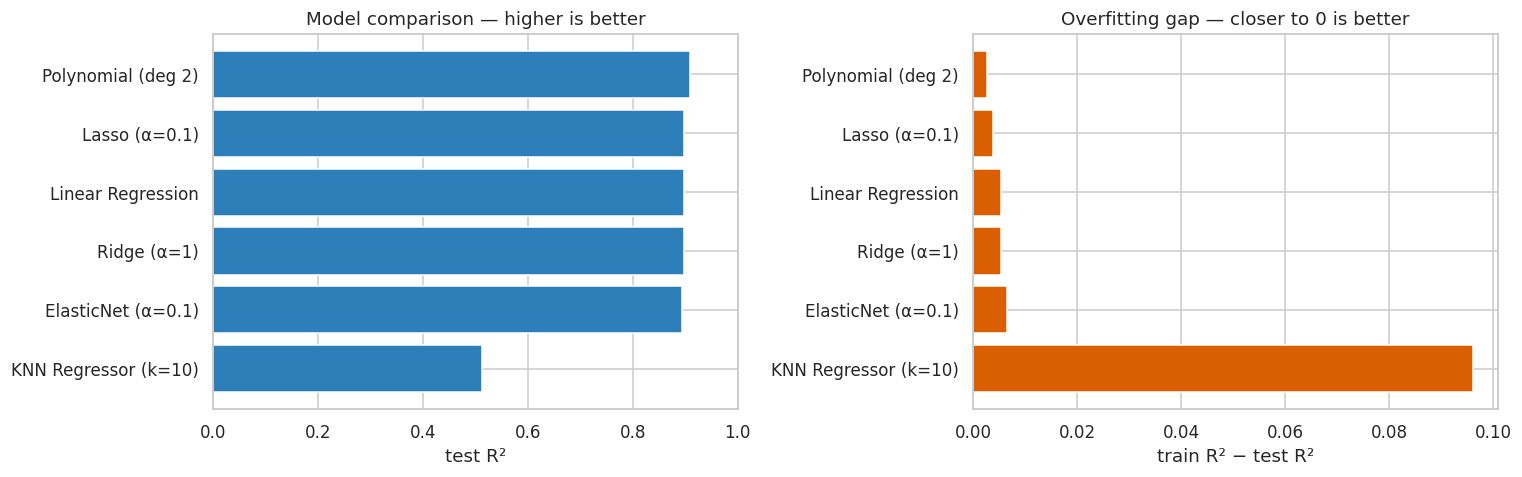

In [25]:
res_df = pd.DataFrame(results).set_index("model").round(4)
res_df["overfit_gap"] = (res_df["train_r2"] - res_df["test_r2"]).round(4)
print("REGRESSION — predicting the exam score\n")
print(res_df.sort_values("test_r2", ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_df = res_df.sort_values("test_r2")
axes[0].barh(plot_df.index, plot_df["test_r2"], color="#2c7fb8")
axes[0].set_xlabel("test R²"); axes[0].set_title("Model comparison — higher is better")
axes[0].set_xlim(0, 1)
axes[1].barh(plot_df.index, plot_df["overfit_gap"], color="#d95f02")
axes[1].set_xlabel("train R² − test R²")
axes[1].set_title("Overfitting gap — closer to 0 is better")
fig.tight_layout(); plt.show()

In [26]:
# Classification comparison
clf_results = []
for name, model, Xtr, Xte in [
    ("Logistic Regression", LogisticRegression(max_iter=2000), Xc_train_s, Xc_test_s),
    (f"KNN (k={best_k})", KNeighborsClassifier(n_neighbors=best_k), Xc_train_s, Xc_test_s),
    ("KNN (k=1)", KNeighborsClassifier(n_neighbors=1), Xc_train_s, Xc_test_s),
]:
    model.fit(Xtr, yc_train)
    p = model.predict(Xte)
    pr = model.predict_proba(Xte)[:, 1]
    clf_results.append({
        "model": name,
        "train_acc": model.score(Xtr, yc_train),
        "test_acc": accuracy_score(yc_test, p),
        "roc_auc": roc_auc_score(yc_test, pr),
    })

clf_df = pd.DataFrame(clf_results).set_index("model").round(4)
print("CLASSIFICATION — predicting pass/fail\n")
print(clf_df.to_string())

CLASSIFICATION — predicting pass/fail

                     train_acc  test_acc  roc_auc
model                                            
Logistic Regression     0.9300     0.915   0.9766
KNN (k=10)              0.8438     0.805   0.8318
KNN (k=1)               1.0000     0.685   0.5957


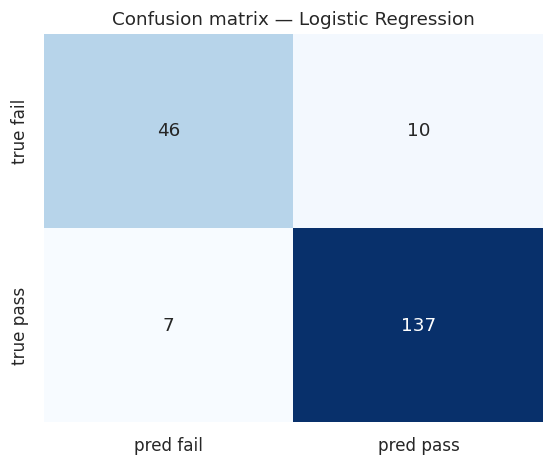

true negatives    46   false positives   10
false negatives    7   true positives   137

precision (of predicted passes, how many really passed): 0.932
recall    (of real passes, how many we caught)          : 0.951


In [27]:
# Where does the best classifier go wrong? (Week 9-10 goes much deeper on this.)
best_clf = LogisticRegression(max_iter=2000).fit(Xc_train_s, yc_train)
cm = confusion_matrix(yc_test, best_clf.predict(Xc_test_s))

fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred fail", "pred pass"],
            yticklabels=["true fail", "true pass"], ax=ax)
ax.set_title("Confusion matrix — Logistic Regression")
fig.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"true negatives  {tn:>4}   false positives {fp:>4}")
print(f"false negatives {fn:>4}   true positives  {tp:>4}")
print(f"\nprecision (of predicted passes, how many really passed): {tp/(tp+fp):.3f}")
print(f"recall    (of real passes, how many we caught)          : {tp/(tp+fn):.3f}")

---
## Mini-challenge

1. Build a **3-class** target with `pd.cut` (`low` / `medium` / `high` score) and fit a
   multinomial logistic regression. Inspect `predict_proba` — it now has three columns.
2. Fit `KNeighborsClassifier` with `weights="distance"` and `metric="manhattan"`.
   Does either change beat the default?
3. Manually implement Ridge with the modified normal equation
   $\mathbf{w}=(X^TX+\alpha I)^{-1}X^T\mathbf{y}$ and check it matches `sklearn.Ridge`
   (remember: do not penalise the intercept).
4. Add the interaction feature `study_hours × mental_health_rating` to the linear model.
   Does test R² improve?
5. Train on **only** `study_hours_per_day`. How much of the 0.9 R² comes from that one
   column? What does that tell you about the other 14 features?

In [28]:
# --- your workspace for the mini-challenge ---

---
## Recap

| Model | Predicts | Key hyperparameter | Needs scaling? |
|---|---|---|---|
| `LinearRegression` | a number | — | no (but helps interpretation) |
| `PolynomialFeatures` + linear | a curve | `degree` | yes |
| `Ridge` | a number | `alpha` (L2) | **yes** |
| `Lasso` | a number, with feature selection | `alpha` (L1) | **yes** |
| `ElasticNet` | both | `alpha`, `l1_ratio` | **yes** |
| `LogisticRegression` | a probability → class | `C` (= 1/alpha) | **yes** |
| `KNeighborsClassifier` | a class by majority vote | `n_neighbors` | **yes** |

**Ideas that transfer to every model you will ever use:**

- Fit the scaler on **train only**; transform both.
- Train score ≫ test score = overfitting. Watch the gap, not just the score.
- More capacity is not better — the test curve peaks and then falls.
- Regularisation trades a little bias for a lot less variance.
- Always look at residuals / the confusion matrix, never at a single number.

**Result on this dataset:** study hours alone explains most of the exam score. Plain linear
regression reaches R² ≈ 0.90 on the test set; a degree-2 polynomial nudges it to ≈ 0.91, and
Ridge/Lasso change essentially nothing. KNN trails badly at R² ≈ 0.51 because distance in
19 dimensions is mostly noise. The lesson is not "polynomials win" — it is that when one
feature carries a clean linear signal, a simple model is very hard to beat, and the extra
complexity buys you one point of R² at the cost of interpretability.

**Next:** `week09_10_evaluation_pipelines_clustering.ipynb` — proper evaluation with
cross-validation and ROC-AUC, `Pipeline` objects that make leakage impossible, and
unsupervised learning.